# 08. Stacking — Meta Model (OOF 기반)

각 feature set 노트북(01~07)이 만든 **OOF 예측**들을 모아 ① 상관관계로 다양성을 진단하고, ② 이 OOF들을 입력으로 **최종 AutoGluon(Meta Model)** 을 5-fold CV 로 학습한 뒤, ③ test 예측들로 최종 추론하여 **`submission_stacking.csv`** 를 생성합니다.

> 좋은 앙상블은 강한 모델의 조합이 아니라 **서로 다른 실수를 하는 모델**의 조합입니다. CV 가 낮은 set 도 OOF 상관이 낮으면 메타에서 가치가 생길 수 있습니다.

## 0. 설치 & 라이브러리

In [1]:
import sys
!{sys.executable} -m pip install ipython-autotime
!{sys.executable} -m pip install autogluon.tabular

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
%load_ext autotime

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from autogluon.tabular import TabularPredictor
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('autogluon').setLevel(logging.ERROR)

# 한글 폰트
import platform
from matplotlib import font_manager, rc

system_name = platform.system()

if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin': 
    plt.rc('font', family='AppleGothic') # MacOS
else:  
    plt.rc('font', family='NanumGothic') # Linux (Colab, Ubuntu 등)

pd.set_option('display.max_columns', 100)

SEED       = 42
N_SPLITS   = 5
TIME_LIMIT = 300
PRESETS    = 'good_quality'

DATA_DIR = '../../data/raw'
OOF_DIR  = '../../outputs/oof'
SUB_DIR  = '../../outputs/submissions'
os.makedirs(SUB_DIR, exist_ok=True)

# 스태킹에 사용할 feature set 이름 (01~07 노트북과 일치)
SETNAMES = ['manual_extended', 'w2v_corner', 'w2v_brand', 'w2v_team',
            'w2v_part', 'category', 'behavior']

time: 2.3 s (started: 2026-06-05 21:40:46 +09:00)


## 1. OOF / test 예측 로드 & 병합
모든 파일을 `custid` 기준 정렬·merge 하고, 길이·custid 정합성을 `assert` 로 검증합니다.

In [5]:
y_train  = pd.read_csv(f'{DATA_DIR}/y_train.csv', encoding='cp949')
folds_df = pd.read_csv(f'{OOF_DIR}/folds.csv')

# ---- OOF (train) ----
oof = y_train[['custid', 'gender']].merge(folds_df, on='custid', how='inner')
for sn in SETNAMES:
    df = pd.read_csv(f'{OOF_DIR}/oof_{sn}_0.csv')[['custid', 'pred_proba']]
    df = df.rename(columns={'pred_proba': f'P_{sn}'})
    oof = oof.merge(df, on='custid', how='inner')
oof = oof.sort_values('custid').reset_index(drop=True)

# ---- test ----
test = None
for sn in SETNAMES:
    df = pd.read_csv(f'{OOF_DIR}/test_{sn}_0.csv')[['custid', 'pred_proba']]
    df = df.rename(columns={'pred_proba': f'P_{sn}'})
    test = df if test is None else test.merge(df, on='custid', how='inner')
test = test.sort_values('custid').reset_index(drop=True)

P_COLS = [f'P_{sn}' for sn in SETNAMES]

# ---- 정합성 검증 ----
assert len(oof) == len(y_train), 'OOF 행 수 불일치'
assert oof[P_COLS].isna().sum().sum() == 0, 'OOF 결측 존재'
assert test[P_COLS].isna().sum().sum() == 0, 'test 결측 존재'
print('OOF :', oof.shape, '| test :', test.shape)
display(oof.head())

OOF : (30000, 10) | test : (19995, 8)


,custid,gender,fold,P_manual_extended,P_w2v_corner,P_w2v_brand,P_w2v_team,P_w2v_part,P_category,P_behavior
0,0,1,3,0.548957,0.302711,0.382588,0.283558,0.340368,0.232487,0.423385
1,1,1,1,0.286338,0.309178,0.321690,0.247447,0.383239,0.321339,0.286152
2,2,1,0,0.676689,0.569946,0.469630,0.283752,0.406963,0.337024,0.322337
3,3,0,0,0.317956,0.336830,0.349854,0.319287,0.388523,0.332476,0.194496
4,4,0,0,0.200011,0.280194,0.161385,0.269717,0.172927,0.266029,0.307406


time: 140 ms (started: 2026-06-05 21:40:52 +09:00)


## 2. 각 set 단독 OOF 성능 요약
AUC(순위) + LogLoss/Brier(칼리브레이션)로 base learner 별 품질을 비교합니다.

In [8]:
y_true = oof['gender'].values
rows = []
for sn in SETNAMES:
    p = oof[f'P_{sn}'].values
    rows.append({
        'set': sn,
        'AUC':     roc_auc_score(y_true, p),
        'LogLoss': log_loss(y_true, p),
        'Brier':   brier_score_loss(y_true, p),
    })
perf = pd.DataFrame(rows).sort_values('AUC', ascending=False).reset_index(drop=True)
display(perf.style.format({'AUC':'{:.5f}','LogLoss':'{:.5f}','Brier':'{:.5f}'}))

,set,AUC,LogLoss,Brier
0,manual_extended,0.69143,0.56215,0.19033
1,w2v_brand,0.67240,0.57363,0.19495
2,w2v_corner,0.66793,0.57617,0.19594
3,behavior,0.64811,0.58224,0.19811
4,w2v_part,0.64770,0.58681,0.20017
5,category,0.58257,0.60458,0.20743
6,w2v_team,0.54573,0.61142,0.21039


time: 125 ms (started: 2026-06-05 21:40:54 +09:00)


## 3. OOF 상관관계 — 다양성 진단
상관이 낮을수록 **서로 다른 관점**(다른 실수) → 스태킹 가치가 큽니다.

,manual_extended,w2v_corner,w2v_brand,w2v_team,w2v_part,category,behavior
manual_extended,1.000,0.686,0.665,0.259,0.704,0.444,0.747
w2v_corner,0.686,1.000,0.840,0.272,0.776,0.349,0.360
w2v_brand,0.665,0.840,1.000,0.241,0.733,0.322,0.354
w2v_team,0.259,0.272,0.241,1.000,0.296,0.485,0.159
w2v_part,0.704,0.776,0.733,0.296,1.000,0.353,0.313
category,0.444,0.349,0.322,0.485,0.353,1.000,0.434
behavior,0.747,0.360,0.354,0.159,0.313,0.434,1.000


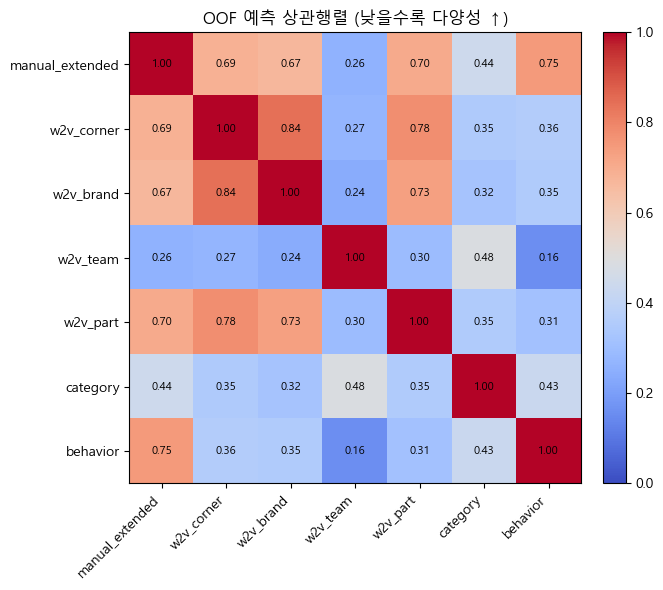

평균 상관(자기자신 제외): 0.466
time: 250 ms (started: 2026-06-05 21:40:55 +09:00)


In [11]:
corr = oof[P_COLS].corr()
corr.index = SETNAMES; corr.columns = SETNAMES
display(corr.style.format('{:.3f}').background_gradient(cmap='coolwarm', vmin=0, vmax=1))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=0, vmax=1)
ax.set_xticks(range(len(SETNAMES))); ax.set_xticklabels(SETNAMES, rotation=45, ha='right')
ax.set_yticks(range(len(SETNAMES))); ax.set_yticklabels(SETNAMES)
for i in range(len(SETNAMES)):
    for j in range(len(SETNAMES)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('OOF 예측 상관행렬 (낮을수록 다양성 ↑)')
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

print('평균 상관(자기자신 제외): %.3f' % ((corr.values.sum() - len(SETNAMES)) / (len(SETNAMES)**2 - len(SETNAMES))))

## 4. Meta Model — 5-fold CV (OOF 위에서 leakage 없이)
입력은 7개 set 의 OOF 확률 7컬럼. base 노트북과 동일한 fold split 을 사용합니다.

In [13]:
# ===== 메타 입력: 기본은 7개 OOF 확률 컬럼만 =====
meta_cols = list(P_COLS)

# --- (선택) 간단한 파생 컬럼: 필요하면 주석 해제 ---
# oof['P_mean'] = oof[P_COLS].mean(axis=1)
# oof['P_std']  = oof[P_COLS].std(axis=1)
# oof['P_rng']  = oof[P_COLS].max(axis=1) - oof[P_COLS].min(axis=1)
# test['P_mean'] = test[P_COLS].mean(axis=1)
# test['P_std']  = test[P_COLS].std(axis=1)
# test['P_rng']  = test[P_COLS].max(axis=1) - test[P_COLS].min(axis=1)
# meta_cols = list(P_COLS) + ['P_mean', 'P_std', 'P_rng']

meta_oof  = np.zeros(len(oof))
meta_test = np.zeros(len(test))

for f in range(N_SPLITS):
    tr_idx = oof.index[oof['fold'] != f]
    va_idx = oof.index[oof['fold'] == f]
    train_part = oof.loc[tr_idx, meta_cols + ['gender']]
    valid_part = oof.loc[va_idx, meta_cols]

    meta = TabularPredictor(
        label='gender', problem_type='binary',
        eval_metric='roc_auc', verbosity=0,
    ).fit(train_data=train_part, presets=PRESETS, time_limit=TIME_LIMIT)

    pos = meta.positive_class
    meta_oof[va_idx] = meta.predict_proba(valid_part)[pos].values
    meta_test += meta.predict_proba(test[meta_cols])[pos].values / N_SPLITS
    print(f'[meta fold {f}] AUC = {roc_auc_score(oof.loc[va_idx,"gender"], meta_oof[va_idx]):.5f}')

		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is

[meta fold 0] AUC = 0.70989


		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is

[meta fold 1] AUC = 0.69862


		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is

[meta fold 2] AUC = 0.70233


		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is

[meta fold 3] AUC = 0.69307


		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is

[meta fold 4] AUC = 0.71436
time: 19min 24s (started: 2026-06-05 21:41:29 +09:00)


## 5. 메타 CV 성능 vs 단일 best set
스태킹이 최고의 단일 set 보다 개선되는지 확인합니다.

In [15]:
meta_auc   = roc_auc_score(y_true, meta_oof)
meta_ll    = log_loss(y_true, meta_oof)
meta_brier = brier_score_loss(y_true, meta_oof)
best = perf.iloc[0]

print('=== Stacking Meta Model CV ===')
print(f'AUC      : {meta_auc:.5f}   (best single: {best.AUC:.5f}, set={best.set})')
print(f'LogLoss  : {meta_ll:.5f}   (best single: {best.LogLoss:.5f})')
print(f'Brier    : {meta_brier:.5f}   (best single: {best.Brier:.5f})')
print(f'\nAUC 개선폭: {meta_auc - best.AUC:+.5f}')

=== Stacking Meta Model CV ===
AUC      : 0.70308   (best single: 0.69143, set=manual_extended)
LogLoss  : 0.55575   (best single: 0.56215)
Brier    : 0.18791   (best single: 0.19033)

AUC 개선폭: +0.01165
time: 16 ms (started: 2026-06-05 22:01:28 +09:00)


## 6. 최종 전체 학습 & 제출 파일 생성

In [17]:
# 전체 OOF 로 메타모델 재학습 후 test 추론
final_meta = TabularPredictor(
    label='gender', problem_type='binary',
    eval_metric='roc_auc', verbosity=0,
).fit(train_data=oof[meta_cols + ['gender']], presets=PRESETS, time_limit=TIME_LIMIT)

pos = final_meta.positive_class
final_test_pred = final_meta.predict_proba(test[meta_cols])[pos].values

# fold 평균(meta_test)과 전체학습(final_test_pred) 중 fold 평균이 OOF 와 더 일관적
submission = pd.DataFrame({'custid': test['custid'].values, 'gender': meta_test})
submission.to_csv(f'{SUB_DIR}/submission_stacking_0.csv', index=False)
print('저장:', f'{SUB_DIR}/submission_stacking_0.csv', submission.shape)
display(submission.head())

		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.5.0`.
		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 
		`import lightgbm` failed. A quick ti

저장: ../../outputs/submissions/submission_stacking_0.csv (19995, 2)


,custid,gender
0,30000,0.452797
1,30001,0.607957
2,30002,0.433150
3,30003,0.073837
4,30004,0.389104


time: 5min 12s (started: 2026-06-05 22:01:40 +09:00)
